In [1]:
from hossam import load_data
from pandas import DataFrame, melt
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sb
from math import sqrt
# 가정 확인을 위한 라이브러리
from scipy.stats import t, normaltest, bartlett, levene
# 분산분석을 위한 라이브러리
from pingouin import anova
from pingouin import welch_anova
# 사후검정을 위한 라이브러리
from pingouin import pairwise_tukey, pairwise_gameshowell

In [2]:
my_dpi = 200 # 이미지 선명도(100~300)
fpath = "./NotoSansKR-Regular.ttf" # 한글을 지원하는 폰트 파일의 경로
fm.fontManager.addfont(fpath) # 폰트의 글꼴을 시스템에 등록함
fprop = fm.FontProperties(fname=fpath) # 폰트의 속성을 읽어옴
fname = fprop.get_name() # 읽어온 속성에서 폰트 이름 추출
plt.rcParams['font.family'] = fname # 그래프에 한글 폰트 적용
plt.rcParams['font.size'] = 6 # 기본 폰트 크기
plt.rcParams['axes.unicode_minus'] = False # 그래프에 마이너스 깨짐 방지 

📘 연습문제

📝 문제 1<br>
poisons 데이터셋은 독극물 종류별로 동물의 생존시간을 기록한 실험 데이터이다.<br>
사용된 독극물 종류와 치료 유형에 유의미한 차이가 있는지 분석하라.<br>

In [3]:
poisons = load_data('poisons')
t(f"행 개수: {poisons.shape[0]}")
print("\n===== 타입확인 =====")
print(poisons.info())
poisons.head()

[data] https://data.hossam.kr/data/lab10_/poisons.xlsx
[desc] 독극물 종류별로 동물의 생존시간을 기록한 실험 데이터 (출처: 방송통신대학교 통계학 개론)

field    description
-------  ------------------
time     동물의 생존시간
poison   사용된 독극물 종류
treat    사용되는 치료 유형


===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   time    360 non-null    float64
 1   poison  360 non-null    object 
 2   treat   360 non-null    object 
dtypes: float64(1), object(2)
memory usage: 8.6+ KB
None


,time,poison,treat
0,3.8,P1,T1
1,2.7,P1,T1
2,1.7,P1,T1
3,2.2,P1,T1
4,0.7,P1,T1


In [4]:
df = melt(poisons, id_vars='time',
value_vars=['poison', 'treat'],
var_name='독극물 종류', value_name='치료 유형')
df.head()

,time,독극물 종류,치료 유형
0,3.8,poison,P1
1,2.7,poison,P1
2,1.7,poison,P1
3,2.2,poison,P1
4,0.7,poison,P1


독극물 종류별 치료유형에 따라 생존 시간 비교

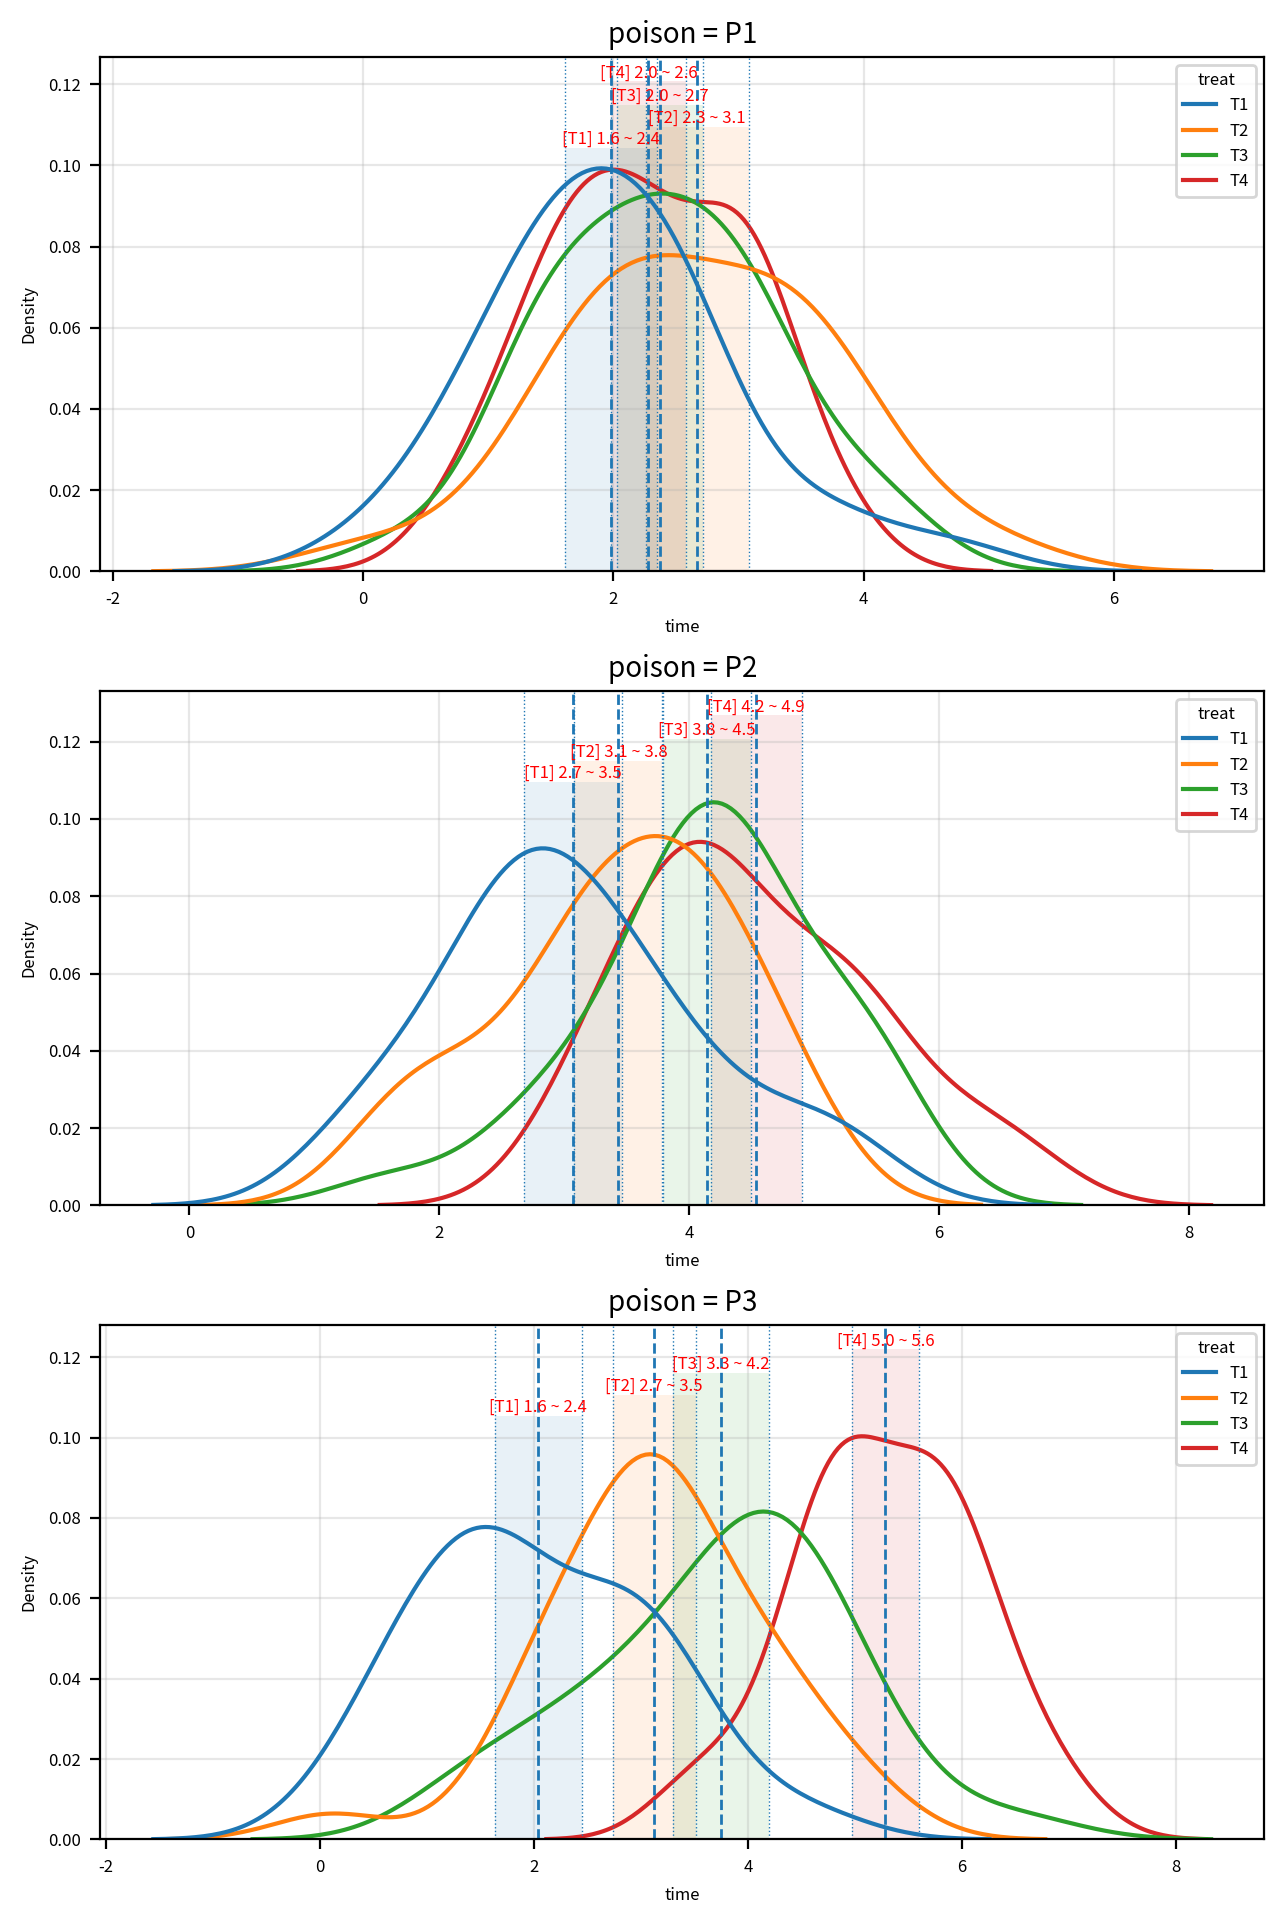

In [5]:
field = 'time'
group_field = 'poison'
hue_field = 'treat'
# 시각화 할 필드만 원본 데이터에서 추출
data = poisons[[field, group_field, hue_field]]
group_values = data[group_field].unique()
group_count = len(group_values)
hue_values = data[hue_field].unique()
# 1) 그래프 초기화
rows = group_count # 그래프 행 수
cols = 1 # 그래프 열 수
width_px = 1280 * cols # 그래프 가로 크기
height_px = 640 * rows # 그래프 세로 크기
figsize = (width_px / my_dpi, height_px / my_dpi)
# ax 객체가 행,열 수에 따라서 리스트가 된다.
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)
for i, v in enumerate(group_values):
    temp = data[data[group_field] == v]
    sb.kdeplot(data=temp, x=field, hue=hue_field, ax=ax[i])
    ax[i].grid(True, alpha=0.3)
    ax[i].set_title('{0} = {1}'.format(group_field, v), fontsize=10,
        pad=5)

    for h in hue_values:
        temp_sub = temp[temp[hue_field] == h]
        # 신뢰구간
        max = temp_sub[field].max() # 최대값
        clevel = 0.95 # 신뢰수준
        dof = len(temp_sub[field]) - 1 # 자유도
        sp_mean = temp_sub[field].mean() # 표본평균
        sp_std = temp_sub[field].std(ddof=1) # 표본표준편차
        sp_std_error = sp_std / sqrt(len(temp_sub[field])) # 표본표준오차
        cmin, cmax = t.interval(clevel, dof, loc=sp_mean,
        scale=sp_std_error)
        ax[i].axvline(cmin, linestyle=':', linewidth=0.5)
        ax[i].axvline(cmax, linestyle=':', linewidth=0.5)
        # 평균 표시
        ymin, ymax = ax[i].get_ylim()
        ax[i].fill_between([cmin, cmax], 0, ymax, alpha=0.1)
        ax[i].axvline(sp_mean, linestyle='--', linewidth=1)

        # 텍스트 그리기
        ax[i].text(x=(cmax-cmin)/2+cmin,
            y=ymax,
            s="[%s] %0.1f ~ %0.1f" % (h, cmin, cmax),
            horizontalalignment="center",
            verticalalignment="bottom",
            fontdict={"size": 6, "color": "red"})
    
# 4) 출력
plt.tight_layout() # 여백 제거
plt.show() # 그래프 화면 출력
plt.close() # 그래프 작업 종료


독 유형에 따른 생존시간

In [6]:
print(poisons['poison'].unique())

['P1' 'P2' 'P3']


In [7]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================
# 1. 사후검정 함수 정의
# ============================
def tukey_by_poison(data, time_col='time', poison_col='poison', treat_col='treat'):
    results = {}
    for p in data[poison_col].unique():
        subset = data[data[poison_col] == p]
        tukey = pairwise_tukeyhsd(
            endog=subset[time_col],
            groups=subset[treat_col],
            alpha=0.05
        )
        results[p] = tukey
    return results


# ============================
# 2. 사후검정 실행
# ============================
tukey_results = tukey_by_poison(poisons)

# 각 poison별 결과 출력
for p, res in tukey_results.items():
    print(f"\n========== Tukey HSD 결과: poison = {p} ==========")
    print(res.summary())



========== Tukey HSD 결과: poison = P1 ==========
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    T1     T2     0.69 0.0318  0.0428 1.3372   True
    T1     T3     0.39 0.3993 -0.2572 1.0372  False
    T1     T4      0.3 0.6229 -0.3472 0.9472  False
    T2     T3     -0.3 0.6229 -0.9472 0.3472  False
    T2     T4    -0.39 0.3993 -1.0372 0.2572  False
    T3     T4    -0.09 0.9836 -0.7372 0.5572  False
---------------------------------------------------

========== Tukey HSD 결과: poison = P2 ==========
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    T1     T2   0.3633 0.4776 -0.2947 1.0213  False
    T1     T3   1.0733 0.0002  0.4153 1.7313   True
    T1     T4   1.4667    0.0  0.8087 2.1247   True
    T2     T3     0.71 0.0291   0.052  1.368   True
    T2     T4   1.

In [8]:
subset_P3 = poisons[poisons['poison']=='P3']

tukey_P3 = pairwise_tukeyhsd(
    endog=subset_P3['time'],
    groups=subset_P3['treat'],
    alpha=0.05
)

print(tukey_P3.summary())

meandiff = ['meandiff']
 
if meandiff < 0.05:
    print(f"차이가 크다")

else:
    print(f"차이가 거의 나지 않는다.")

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    T1     T2   1.0833 0.0007  0.3742 1.7925   True
    T1     T3     1.71    0.0  1.0009 2.4191   True
    T1     T4   3.2467    0.0  2.5375 3.9558   True
    T2     T3   0.6267 0.1031 -0.0825 1.3358  False
    T2     T4   2.1633    0.0  1.4542 2.8725   True
    T3     T4   1.5367    0.0  0.8275 2.2458   True
---------------------------------------------------


TypeError: '<' not supported between instances of 'list' and 'float'

In [ ]:
for idx, row in tk_df.iterrows():
    pval = float(row['p-adj'])
    g1, g2 = row['group1'], row['group2']

    if pval < 0.05:
        print(f"{g1} vs {g2}: p={pval:.4f} → 유의미한 차이 있음")
    else:
        print(f"{g1} vs {g2}: p={pval:.4f} → 차이가 없음")


T1 vs T2: p=0.0007 → 유의미한 차이 있음
T1 vs T3: p=0.0000 → 유의미한 차이 있음
T1 vs T4: p=0.0000 → 유의미한 차이 있음
T2 vs T3: p=0.1031 → 차이가 없음
T2 vs T4: p=0.0000 → 유의미한 차이 있음
T3 vs T4: p=0.0000 → 유의미한 차이 있음


In [ ]:
import pandas as pd

# Tukey 결과 → DataFrame 변환
tk_df = pd.DataFrame(
    data=tukey_P3._results_table.data[1:], 
    columns=tukey_P3._results_table.data[0]
)

print(tk_df)
md = tk_df['meandiff'].astype(float).tolist()

tk_df['p_rank'] = tk_df['p-adj'].rank(method='dense', ascending=True)
tk_df.sort_values('p_rank', inplace=True)

print(tk_df[['group1','group2','p-adj','p_rank']])


print(f"T1 vs T3, T1 vs T4 결과 값이 동일한 것으로 나타났다. 즉, T1이 T3,T4에 비해서 값이 크다는 것을 증명할 수 있다.\n")
print(f"또한, 값이 {md[1]}, {md[2]}의 값을 통해 알 수 있는 점은,\n")
print(f"T4가 T3보다 작다는 것을 알 수 있다.")


  group1 group2  meandiff   p-adj   lower   upper  reject
0     T1     T2    1.0833  0.0007  0.3742  1.7925    True
1     T1     T3    1.7100  0.0000  1.0009  2.4191    True
2     T1     T4    3.2467  0.0000  2.5375  3.9558    True
3     T2     T3    0.6267  0.1031 -0.0825  1.3358   False
4     T2     T4    2.1633  0.0000  1.4542  2.8725    True
5     T3     T4    1.5367  0.0000  0.8275  2.2458    True
  group1 group2   p-adj  p_rank
1     T1     T3  0.0000     1.0
2     T1     T4  0.0000     1.0
5     T3     T4  0.0000     1.0
4     T2     T4  0.0000     1.0
0     T1     T2  0.0007     2.0
3     T2     T3  0.1031     3.0
T1 vs T3, T1 vs T4 결과 값이 동일한 것으로 나타났다. 즉, T1이 T3,T4에 비해서 값이 크다는 것을 증명할 수 있다.

또한, 값이 1.71, 3.2467의 값을 통해 알 수 있는 점은,

T4가 T3보다 작다는 것을 알 수 있다.


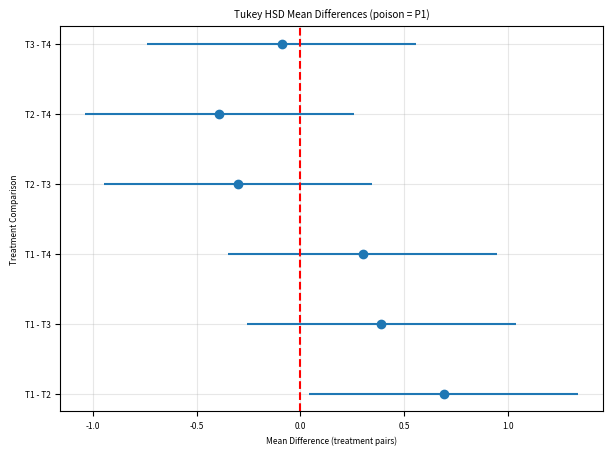

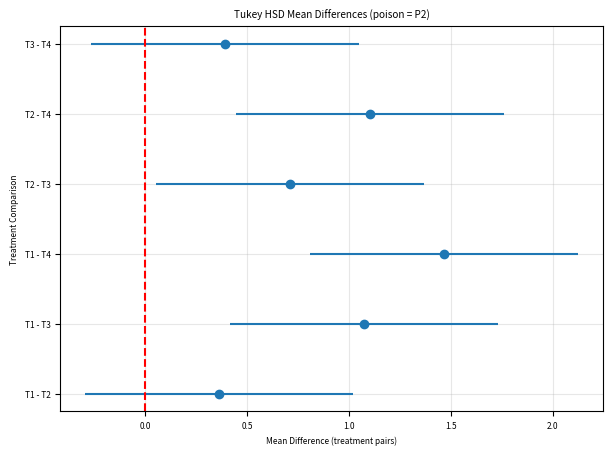

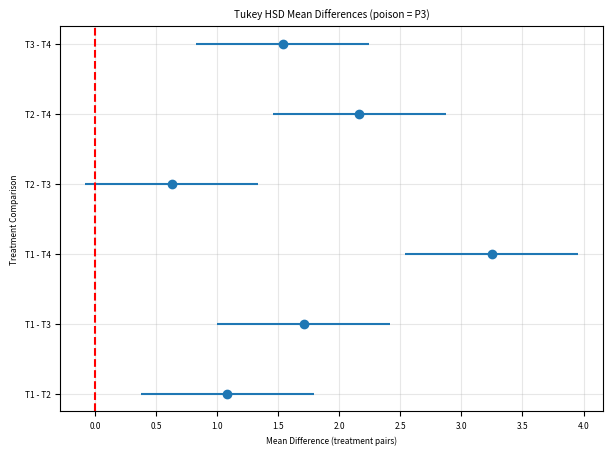

In [ ]:
# ============================
# 3. 사후검정 시각화 함수
# ============================
def plot_tukey_results(tukey_results):
    for p, res in tukey_results.items():
        df = pd.DataFrame(data=res._results_table.data[1:], columns=res._results_table.data[0])
        
        # mean difference, lower/upper bound 추출
        df['meandiff'] = df['meandiff'].astype(float)
        df['lower'] = df['lower'].astype(float)
        df['upper'] = df['upper'].astype(float)
        
        # Plot
        plt.figure(figsize=(7,5))
        plt.errorbar(
            df['meandiff'], 
            df.index, 
            xerr=[df['meandiff'] - df['lower'], df['upper'] - df['meandiff']],
            fmt='o'
        )
        plt.axvline(0, color='red', linestyle='--')
        plt.yticks(df.index, df['group1'] + " - " + df['group2'])
        plt.title(f"Tukey HSD Mean Differences (poison = {p})")
        plt.xlabel("Mean Difference (treatment pairs)")
        plt.ylabel("Treatment Comparison")
        plt.grid(True, alpha=0.3)
        plt.show()

# 실행
plot_tukey_results(tukey_results)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd


(B) 독극물 그룹별 Tukey 사후검정 함수

In [ ]:
def tukey_by_poison(df):
    results = {}

    for p in df['poison'].unique():
        subset = df[df['poison'] == p]

        tukey = pairwise_tukeyhsd(
            endog=subset['time'],
            groups=subset['treat'],
            alpha=0.05
        )

        results[p] = tukey

    return results


tukey_results = tukey_by_poison(poisons)


In [ ]:
def tukey_to_df(tukey):
    df = pd.DataFrame(
        tukey._results_table.data[1:], 
        columns=tukey._results_table.data[0]
    )

    numeric_cols = ['meandiff','p-adj','lower','upper']
    df[numeric_cols] = df[numeric_cols].astype(float)
    return df


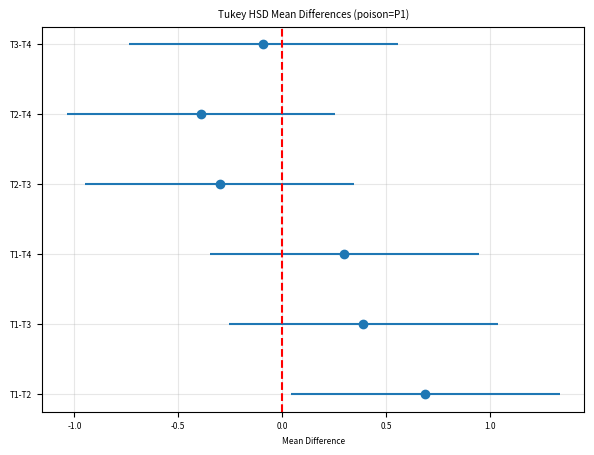

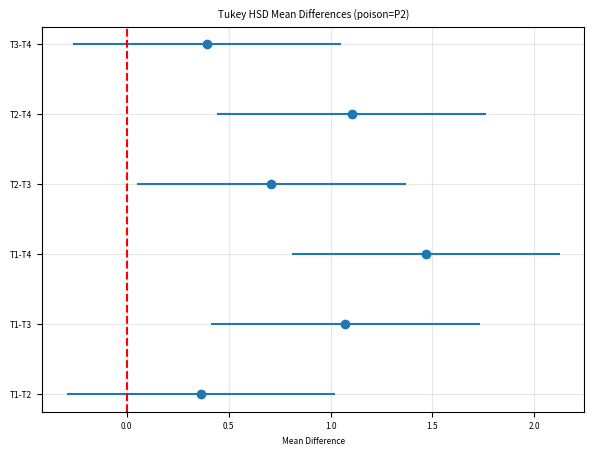

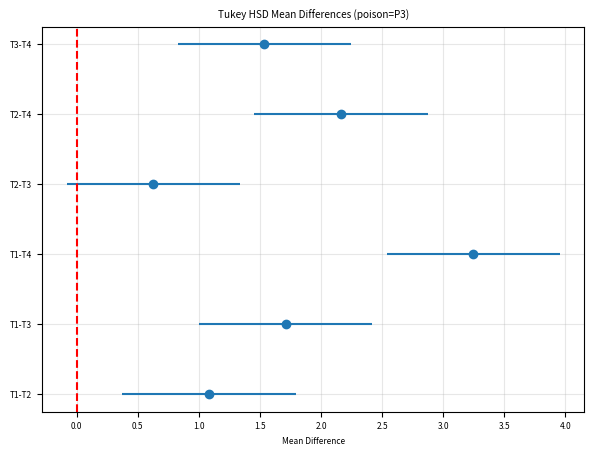

In [ ]:
# Tukey mean difference plot 시각화 함수
def plot_tukey(tukey_results):
    for p, res in tukey_results.items():
        df = tukey_to_df(res)

        plt.figure(figsize=(7,5))
        plt.errorbar(
            df['meandiff'],
            df.index,
            xerr=[df['meandiff'] - df['lower'], df['upper'] - df['meandiff']],
            fmt='o'
        )
        plt.axvline(0, color='red', linestyle='--')

        plt.yticks(df.index, df['group1'] + '-' + df['group2'])
        plt.title(f"Tukey HSD Mean Differences (poison={p})")
        plt.xlabel("Mean Difference")
        plt.grid(True, alpha=0.3)
        plt.show()
plot_tukey(tukey_results)


📝 문제 2<br>
tomato 데이터 셋은 효소 성분의 비료가 효소 함량이 증가함에 따라 토마토 모종 포기의 성장에<br>
어떤 영향을 주는지에 대한 실험 결과이다.<br>
분산분석을 하여 효소 함량에 따라 토마토 모종 성장에 차이가 나는지 검정하라.<br>


In [ ]:
tomato = load_data('tomato')
t(f"행 개수: {tomato.shape[0]}")
print("\n===== 타입확인 =====")
print(tomato.info())
tomato.head()
tomato

[data] https://data.hossam.kr/data/lab10_/tomato.xlsx
[desc] 효소 성분의 비료가 효소 함량이 증가함에 따라 토마토 모종 포기의 성장에 어떤 영향을 주는지에 대한 실험 결과 (출처: 방송통신대학교 통계학 개론)
[!] Cannot read metadata

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   효소함량    90 non-null     int64  
 1   모종성장    90 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 1.5 KB
None


,효소함량,모종성장
0,0,9.5
1,0,10.0
2,0,10.7
3,0,9.0
4,0,12.4
5,0,9.4
6,0,11.4
7,0,10.4
8,0,10.8
9,0,10.7


효소 함량 수준에 따라 성장량의 분산이 어떻게 달라질까?<br>
“효소 함량의 크기에 따라 ‘모종 성장량의 분산(variability)’이 달라지는가?”<br>
즉, 효소 수준이 높을수록 성장량의 변동성이 커지거나 줄어드는가?<br>

In [ ]:
from scipy.stats import levene
tomato['enzyme_group'] = pd.qcut(tomato['효소함량'], q=3, labels=['low','mid','high'])

g1 = tomato[tomato['enzyme_group']=='low']['모종성장']
g2 = tomato[tomato['enzyme_group']=='mid']['모종성장']
g3 = tomato[tomato['enzyme_group']=='high']['모종성장']

stat, p = levene(g1, g2, g3)
print(stat, p)


0.294897252630917 0.745349415286223


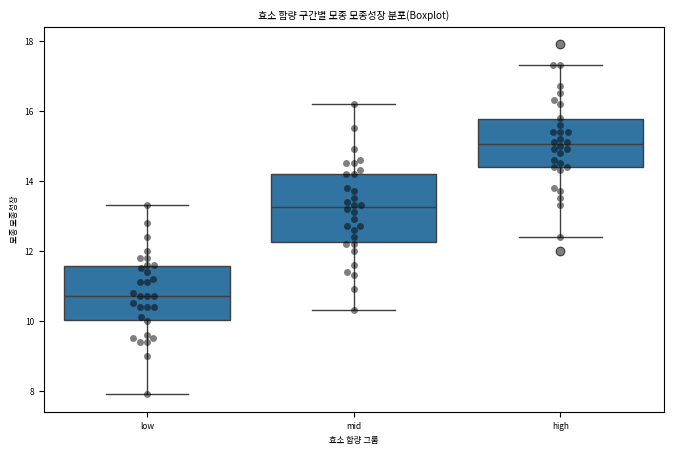

In [ ]:



# 효소 함량을 3분위수 기준으로 low/mid/high 그룹화
tomato['enzyme_group'] = pd.qcut(
    tomato['효소함량'], 
    q=3, 
    labels=['low', 'mid', 'high']
)

tomato.head()
# 1. 효소 그룹별 Boxplot으로 분산 비교 시각화


plt.figure(figsize=(8,5))
sns.boxplot(data=tomato, x='enzyme_group', y='모종성장')
sns.swarmplot(data=tomato, x='enzyme_group', y='모종성장', color='black', alpha=0.5)
plt.title("효소 함량 구간별 모종 모종성장 분포(Boxplot)")
plt.xlabel("효소 함량 그룹")
plt.ylabel("모종 모종성장")
plt.show()



효소 함량이 가장 높은 high그룹에서 값이 가장 크게 나타났다.
즉, 효소 함량이 높을수록 모종 성장이 더 적극적이라는 뜻이다.<br>
또한, 값의 분산이 mid 즉 효소함량이 중간정도인 그룹에서 분산이 큰 것으로 나타났다.<br>

📝 문제 3<br>
edu 데이터 셋은 두 가지 교육방법을 비교하기 위하여 능력이<br> 비슷한 고등학교 학생 22명을 추출<br>
하고, 11명씩 두 집단으로 나누어 한 학기 동안 각각의 <br>교육방법으로 교육시킨 후 치른 학기말 시험 성적을<br> 조사한 자료이다.<br>
이 자료를 이용하여 두 가지 교육방법에 대한 국어와 영어의<br> 효과가 서로 다르다고 할 수 있는지<br>
검정하라. (분석 목적에 맞는 데이터 재배치 과정이
필요합니다.)<br>

In [ ]:
edu = load_data('edu')
t(f"행 개수: {edu.shape[0]}")
print("\n===== 타입확인 =====")
print(edu.info())
edu.head()
edu

[data] https://data.hossam.kr/data/lab10_/edu.xlsx
[desc] 두 가지 교육방법을 비교하기 위하여 능력이 비슷한 고등학교 학생 22명을 추출하고, 11명씩 두 집단으로 나누어 한 학기 동안 각각의 교육방법으로 교육시킨 후 치른 학기말 시험 성적을 조사한 자료 (출처: 방송통신대학교 통계학 개론)
[!] Cannot read metadata

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   교육방법    22 non-null     int64
 1   국어      22 non-null     int64
 2   영어      22 non-null     int64
dtypes: int64(3)
memory usage: 660.0 bytes
None


,교육방법,국어,영어
0,1,65,82
1,1,87,79
2,1,73,85
3,1,79,60
4,1,81,65
5,1,69,70
6,1,55,79
7,1,76,80
8,1,77,76
9,1,70,90


교육방법1과 교육방법2의 국어와 영어의 효과 차이

MANOVA(다변량 분산분석)<br>
국어와 영어점수를 동시에 고려해서<br>
교육 방법의 전체적인 학업 성취 효과 알아보기.<br>
🍭교육방법이 국어와 영어 전체 성취 패턴에 영향을 줄까?


In [ ]:
edu.groupby('교육방법')[['국어','영어']].mean()
from scipy.stats import ttest_ind

g1_kor = edu[edu['교육방법']==1]['국어']
g2_kor = edu[edu['교육방법']==2]['국어']

t_stat, p = ttest_ind(g1_kor, g2_kor, equal_var=False)
g1_eng = edu[edu['교육방법']==1]['영어']
g2_eng = edu[edu['교육방법']==2]['영어']

t_stat, p = ttest_ind(g1_eng, g2_eng, equal_var=False)
print("영어 t-test:", t_stat, p)
print("국어 t-test:", t_stat, p)

if p < 0.05:
    print(f"p-value 값이 {p}>=0.05로, 교육방법이 성취패턴에 영향을 주지 않는다.")

else:
    print(f"p-valu의 값이 {p}<0.05로 보아, 교육방법이 성취 패턴에 영향을 준다고 볼 수 있습니다.")
    


영어 t-test: -1.0353498116503186 0.31346913651485214
국어 t-test: -1.0353498116503186 0.31346913651485214
p-valu의 값이 0.31346913651485214<0.05로 보아, 교육방법이 성취 패턴에 영향을 준다고 볼 수 있습니다.


[data] https://data.hossam.kr/data/lab10_/edu.xlsx
[desc] 두 가지 교육방법을 비교하기 위하여 능력이 비슷한 고등학교 학생 22명을 추출하고, 11명씩 두 집단으로 나누어 한 학기 동안 각각의 교육방법으로 교육시킨 후 치른 학기말 시험 성적을 조사한 자료 (출처: 방송통신대학교 통계학 개론)
[!] Cannot read metadata


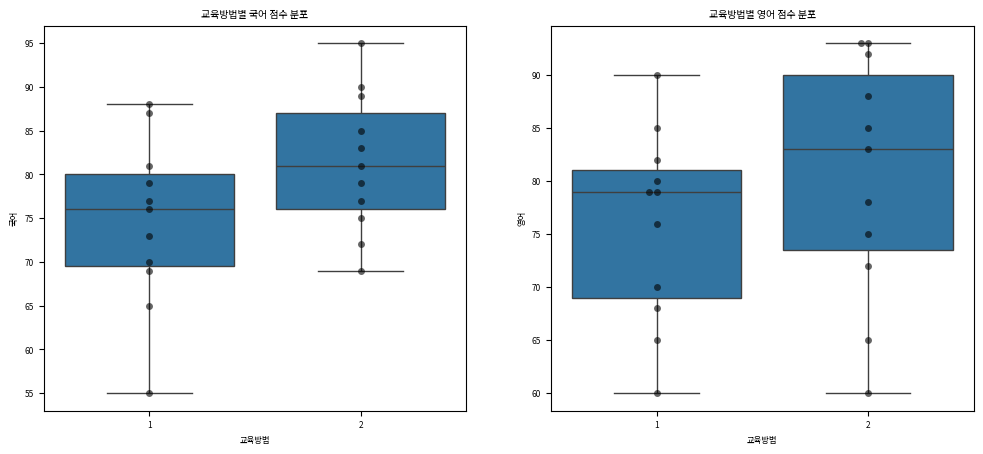

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
edu = load_data('edu')
plt.figure(figsize=(12,5))

# 국어
plt.subplot(1,2,1)
sns.boxplot(data=edu, x='교육방법', y='국어')
sns.swarmplot(data=edu, x='교육방법', y='국어', color='black', alpha=0.6)
plt.title("교육방법별 국어 점수 분포")

# 영어
plt.subplot(1,2,2)
sns.boxplot(data=edu, x='교육방법', y='영어')
sns.swarmplot(data=edu, x='교육방법', y='영어', color='black', alpha=0.6)
plt.title("교육방법별 영어 점수 분포")

plt.show()
